# Analisi Dati in Python

Per prima cosa importiamo le librerie che ci serviranno:  

- Numpy per lavorare con gli array, le funzioni matematiche, ma soprattutto per importare file di testo con la funzione loadtxt();

- Matplotlip.Pyplot per la rappresentazione grafica;

- Da Scipy.Optimize importeremo la funzione curve_fit(),la quale ci consentirà di eseguire regressioni di qualunque tipo (lineari, esponenziali, etc...).

In [2]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# opzionale, a me piace lo stile che da ai grafici di matplotlib,
# per installarla con anaconda usare il comando 'conda install A
import scienceplots
plt.style.use(['science', 'notebook'])

ModuleNotFoundError: No module named 'scienceplots'

In [3]:
def f(x, A, B):
    return A*x + B

In [4]:
x = np.linspace(0, 10, 25)
y = f(x, 1, -2)

In [8]:
err = np.random.normal(size=25)
y_err = y + err

In [9]:
popt, pcov = curve_fit(f, x, y_err)

In [11]:
popt

array([ 0.9551792 , -1.67067118])

In [12]:
pcov

array([[ 0.0045238 , -0.02261898],
       [-0.02261898,  0.15393474]])

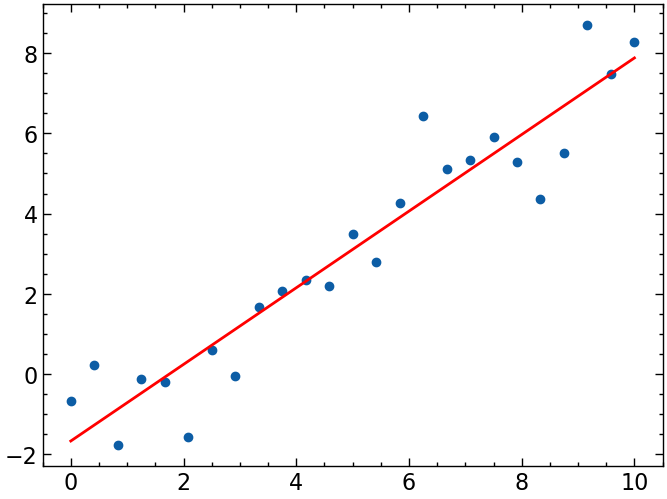

In [40]:
plt.scatter(x, y_err)

A_fit, B_fit = popt

y_fit = f(x, A_fit, B_fit)

plt.plot(x, y_fit, color='red')

In [26]:
errs = np.sqrt(np.diag(pcov))

print(f'A = {A_fit:.2f} +- {errs[0]:.2f}, B = {B_fit:.2f} +- {errs[1]:.2f}')

A = 0.96 +- 0.07, B = -1.67 +- 0.39


In [28]:
data = np.loadtxt(r'/Users/aserra/Università/FFC_2024/Codici_Prova/Lezione_30-04/exp_g.txt', skiprows=2)

In [33]:
def f_gravit(x, G):
    return 0.5 * G * x**2

In [34]:
x_g = data[:,0]
y_g = data[:,1]

popt_g, pcov_g = curve_fit(f_gravit, x_g, y_g)

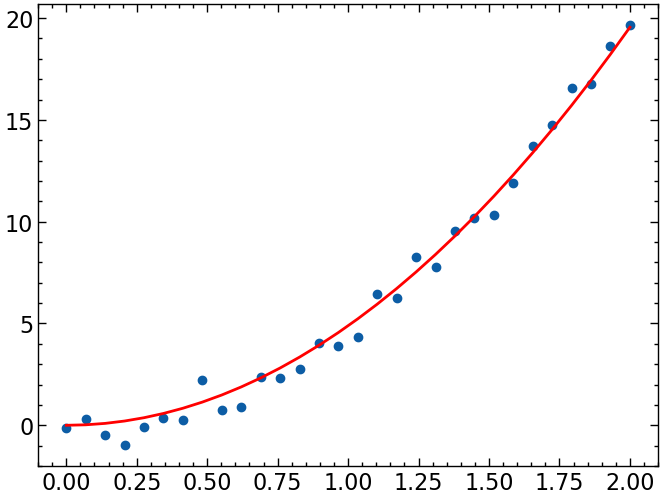

In [39]:
y_fit_g = f_gravit(x_g, popt_g[0])

plt.scatter(x_g, y_g)
plt.plot(x_g, y_fit_g, color='r')